In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
import plotly.express as px
np.set_printoptions(precision=2,suppress=True)

# LDA

In the previous chapter, we performed dimensionality reduction using Principal Component Analysis (PCA) on a dataset of handwritten digits. Notice that we did not use the labels indicating which digit each data point represented. Instead, we looked for directions that maximize the variance of the data, hoping that data points belonging to the same digit would form clusters. An algorithm that does not use class labels is called **unsupervised**.

In this chapter, we will study **Linear Discriminant Analysis** (**LDA**). Like PCA, LDA can be used for dimensionality reduction, but unlike PCA, it takes class labels into account. Algorithms that use labeled data are called **supervised** algorithms.

The main goal of LDA is to find directions that separate different classes as well as possible. To achieve this, we want to maximize the separation between class means while minimizing the spread of data points within each class. Ideally, points belonging to the same class form a tight cluster, while points belonging to different classes are well separated.

It might seem that LDA is simply a better alternative to PCA, but this is not the case. PCA and LDA optimize different objectives, and either method may be more useful depending on the dataset and the task. In practice, however, it is quite common to use both algorithms sequentially.

Consider the image below. Our data consists of two classes, shown in red and blue. Suppose we want to find a line onto which we can project the data so that the two classes are well separated. 

One approach is to maximize the distance between the class means, $m_1$ and $m_2$, of the two classes. For more than two classes, it is convenient to measure the distances between the mean of each class and the overall mean, $M$. This leads to the concept of **between-class scatter**. 

However, separating the class means is not enough. If the data points within each class are widely spread out, the projected classes may overlap. We therefore also want to minimize the spread of the data within each class.  This leads to the concept of  **within-class scatter**.


<center> <img src="data:image/png;base64,  ...
 " width="50%"> </center>

To emphasize why the second condition is important, consider the example below. Projecting the data onto the line $L_1$ maximizes the distance between the class means, but the resulting classes are not well separated. In contrast, projecting the data onto the line $L_2$ produces a much better separation because the within-class spread is smaller relative to the distance between the means.

<center> <img src="data:image/png;base64,  iVBORw0KGgoAAAANSUhEUgAAAp8AAAJWCAYAAAAeD+x0AAAAAXNSR0IArs4c6QAAAARnQU1BAACxjwv8YQUAAAAJcEhZcwAADsMAAA7DAcdvqGQAACRvSURBVHhe7d1NjFxXoeDx42qHMQHEW/AGQsVOtc1AlHZCeBDgLYaP5+4Ob5DsZIFAbBixybwZV3dgMWZGwjbKhg0rEHqwIItEIjs+bUcMEAHh4xF7kQW7jkIUkFgg4u6Ej2B3ndEpd7fLt9vd1dVVp+6t+/tJR5WuW9W6Okl3/3Oqzq0QAQAgk1C8AwAARkV8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCAJCN+AQAIBvxCQBANuITAIBsxCcAANmITwAAshGfAABkIz4BAMhGfAIAkI34BAAgG/EJAEA24hMAgGzEJwAA2YhPAACyEZ8AAGQjPgEAyEZ8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCAJCN+ByB2267LYYQYrvdLh4CAKg18Tlkf/jDH7rhmcajjz5aPAwAUGvic8jOnTu3EZ/PPvts8TAAQK2JzyF75JFHuuF54MCBeOXKleJhAIBaE59D9uCDD3bj87777iseAgCoPfE5ZIcOHerG50MPPVQ8BABQe+JziP74xz9uvN/z61//evEwAEDtic8h+sEPfrARnxcvXiweBgCoPfE5RF/84he74XnLLbfEV199tXgYAKD2xOcQfexjH+vG57333ls8tKWXX345njlzJn70ox+Nb37zm7vP/dSnPlV8GADAxBCfQ3TkyJFuQH76058uHtrS888/3318+kSkFKDiEwCYdOJzSC5fvhz37dvXDcivfOUrxcNb+tvf/hZ/97vfdf/5r3/9q/gEACae+BySp556amOz0S9+8Yvi4R2JTwCgDsTnkHzpS1/qxuPU1FT885//XDy8I/EJANSB+ByST37yk914nJmZKR7qi/gEAOpAfA7JnXfe2Y3HT3ziE91d7NuNrT7zXXwCAHUgPofglVdeiY1GY+M9nzuNb33rW8VvIT4BgFoQn0Pw9NNPbwrM7Ua6xFKR+AQA6kB8loT4BADqQHyWhPgEAOpAfI7Zl7/85fjII490P2Yzxee73vWu7tdp/OQnPyk+HKDrhRdeiJcuXep7pMezM/MKoyc+x+yOO+7Y9J7Q9ZGCFKAoBc/rXvvaTb8zthu3HjgQf/vb3xa/FT3SvN566+s3zd1248CBW7d8Hz9wc+ITJkin0yneVVpVOtfV1dXiXWOVVtzSx/k+FkK8VBgXt7jv8RDivnTs4sXitxqrMs7rtSuXPBZDuFQYF7e47/EYwr74zDPPFL/VWJVtXrdTpd8DVTrXshOfUHErKyvxdLsdj7Va8Xiz2b1NX6f7y6ZK5/r73/8+vvedH4wHpt4RDzTu697ed88H4u9+97viQ7Nbj88UmjGEuBJCXAhvjK1wODbDu7u37fDGuLx2PAVoWeKz7PN6LT6fSdMWQ1iJbwwL8XCYju8OzXg4tOIbw8kYwvLa8RSgjVLEZ5rX9937oU3z+uKLLxYfOnbp531x8Uycnp6Nzebx2GodiydPfj5evrxcfOjYXTvXs1uc6+XiQ9kF8QkVln4xzs3MxAuNRuyshUa6TV+n+8sUdelc5o8evem5Li+X5w9P+kP++gPTcV/4XgyhsxYandgI34uv+0/TYw+l3vhM4Xk03NY9t+K5zoS3dgO0LPGZ5vUNr12f19Wec/1+d17HHUo3xudKvC3cHb8XGnG157/X74dGfGuYiSFcLk18XpvXw3Ff+O4W83p47PPaK/0euPvu++PU1Pkbz7XxZLzrrvn40kvlibp0rvfc85E4NXVui3O9P7700kvFp9Cn8MrVq9EwjGqO/3PyZDzfaHT/MBbHuUYj/t92e9NzxjX6OtcrVzY9bxzjPe/84FogbTrV2Ajfje+550Px5TGe69O//vVGfKYVz6ltzrUd/qH7uBSfP/uP/9j0vXKO99y7Pq/rkdx7rt+7Nq9/H++8rsdnWvH8Xpja+B+l3pGC9B9Ce+2l+Eb86a9+tel75Rz33fuhbef13fd8KK78/e+bnjeO8T8XTq/F3Bbn2jgf/8fJ0+U61/03P9eH/ld5zrVqI4SnnoqGYVRzHH7LWzZWZYoj/dF821vesuk54xqHb7tt53P98Y83PW8cY//UO3pWOoqjE/c33jHec/3a12JYi8/pcHjbc22Ft23EZ/j3f9/8vTKOa/Oa/vAUz3N9Xu8sxbym+DwcDserm0+yO9J/r/8ltNZWSBvjn9f9fczrj3606XljGW/9r9uea3jLB0p2rle2OM/1c/1gDD8syblWbWy6wzCMaowf/zi++01vKv5GvGGk42P9Y74+0rn+4z9uuYp0w7mW4Y/Oj34Ub2m8d8vVjvVxS+O+GH74w83PzTXWIumZEOLt4d3bnmt6D2h63Njjs695fW8p5jWEX8d3h4M3/Z+lNN4Tmt3HjT0+07xOpXm92f+ArM3r/xvjvK6P9LvoP39k23MNb/rX8f43sD665/qv24RyOtf/Vo55reIoLoUahlGd8eFW66ZBl+7/8B13lOal7H9ptW76xzyd67/cccdYX8ruHa/triTd7A9kp7uZY5zn2vuy+84rn0dK87L7rbfcuc0f8zSvd471Zczel913Wvl8W8/K57hfdu9rXl8d37z2junDc9ue66E75uJyac51ftuVz0N3zMflV1/d9Dxj52HDEVRY2imeNuxs8Zux+/7KMwsLxaeMTV/nWpJLmaTd2On9klucavf+977zQ2O97ErvhqNr7/m8+bn2vudz3BuO3nvv+rxuXv1M701M87q6Ot557X3P53f7fM/nuDccpV3u283rfd15Lcfll9LO8WubjbY418aF2G6fLdW57t9/83M9ebI851o14hMqbH23e4q33h3k6euy7na/2bmWcbd7I3yn5w9P2j383RLvdt98rmXd7X7tXHt3ZV+7isC4d2Vvtdv9O4Xd7ik8y7rbvazz2uv6bvfiDvILJd7t/v0tztVu970Qn1Bx6RdkWjWcXbt2ZrpNX5cpPNdV6Vw3rpu4f+26ifvf0V0RHXd4Jltd53Oxe53PI7EZ/ql7m1ZEy3qdzzLP6+brfC7GI2E6/lNoxiPd63ymFc9yXufz/e/68KZ5LVN4rks/7w8/nK6dObd27czZ2G6fLu11Ph9++AtbnGt5IrmKxCdMkHG+FLxbVTrXsr205hOORsMnHOVXpd8DVTrXshOfABXjs91Hw2e7Qx7iE6CCUiillbp+R3o8OzOvMHriEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCAJCN+AQAIBvxCQBANuITAIBsxCcAANmITwAAshGfAABkIz4BAMhGfAIAkI34BAAgG/EJAEA24hMAgGzEJwAA2YhPAACyEZ8AAGQjPgEAyEZ8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCAJCN+AQAIBvxCQBANuITAIBsxCcAANmITwAAshGfAABkIz4BAMhGfAIAkI34BAAgG/EJAEA24hMAgGzEJwAA2YhPAACyEZ8AAGQjPgEAyEZ8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCAJCN+AQAIBvxCQBANuITAIBsxCcAANmITwAAshGfAABkIz4BAMhGfAIAkI34BAAgG/EJAEA24hMAgGzEJwAA2YhPAACyEZ8AAGQjPgEAyEZ8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AmCCdTqd4F0NgXodHfAJAxa2srMQzCwtxdno6Hm8247FWK37+5Mm4vLxcfCi7kOZ1cfFsnJ6ejc3m8dhqHYsnT34+Xr58ufhQdkF8AkCFpUC6/+674/lGI66GEGMIsRNCfLLRiPMzM0JpQGle77nnI3Fq6lwMYTVNawyhExuNJ+Ndd90fX3rppeJT6JP4BIAKSyue56emusG5Vkgb40KjEc+2214yHkBa8dy//3w3OItT22hciCdPno2rq6vFp9EH8QkAFTZ3+HC8WqyjnhXQ+VZLJA3gyJH5GMKV4pSujU5ste6PV69eLT6NPohPAKiotKL5wMGDGy+3bzUeaDZF0i6leT106MEYwtXidG6MZvPBeOXKleJT6YP4BIAK22nlc87K50B2XvmcF/UDEp8AUGHe8zka3vM5OuITACpsfbf7ucJu9xSedrsP7vpu9+8XdrtfsNt9j8QnAFRcCqWzi4txbu06n7OtVjzdbrvO5x6leX344S/E6em5tet8zsZ2+7Sg3yPxCQATxEvso2Feh0d8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCAJCN+AQAIBvxCQBANuITAIBsxCcAANmITwAAshGfAABkIz4BAMhGfAIAkI34BAAgG/EJAEA24hMAgGzEJwAA2YhPAACyEZ8AAGQjPgEAyEZ8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCwA46nU7xLobAvNaT+ASALaysrMQzCwtxdno6Hm8247FWK37+5Mm4vLxcfCi7kOZ1cfFMnJ6ejc3m8dhqHYsnT34+Xr5sXutCfAJAQQqk++++O55vNOJqCDGGEDshxCcbjTg/MxMvX75cfAp9SPN69933x6mp8zGE1TStMYRObDSejHfdNR9fesm81oH4BICCtOJ5fmqqG5xrhbQxLjQa8Uy77SXjASwunl0Lz05xWmOjcSG222fj6upq8WlMGPEJAAVzhw/Hq8U66lkBnW+1RNIAjhyZiyFcLU7p2ujEVms+Xr1qXied+ASAHmlF84GDBzdebt9qPNBsxqtXrxafyjbSvB469EDPy+2bR7P5QLxyxbxOOvEJAAU7rXzOWfkcyM4rn3NWPmtAfAJAgfd8job3fJKITwAoWN/tfq6w2z2Fp93ug7u+2/1cYbf7Bbvda0R8AsAWUiidXVyMc2vX+ZxtteLpdtt1PvcozevDD5+N09Nza9f5nI3t9mnX+awR8QkAO/AS+2iY13oSnwAAZCM+AQDIRnwCAJCN+AQAIBvxCQBANuITAIBsxCcAANmITwAAshGfAABkIz4BAMhGfAIAkI34BAAgG/EJAEA24hMAgGzEJwAA2YhPAACyEZ8AAGQjPgEAyEZ8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCAJCN+AQAIBvxCQBANuITAIBsxCcAANmITwAAshGfAIxFp9Mp3sUQmFfKTnwCkM3Kyko8s7AQj01Px+PNZjzWasXTJ0/G5eXl4kPZhTSvCwtn4vT0bGw2j8dW61g8efLz5pVSEp8AZJECaf7o0Xi+0YirIcQYQuyEEJ9sNOL8zExcvny5+BT6kOb17rvvj43G+RjCaprWGEInNhpPxpmZ+XjZvFIy4hOALNKK54WpqW5wrhXSxrjQaMQz7baXjAeQVjynplJ4dorTGhuNC7HdPmteKRXxCUAWs4cPb6x4FkcK0rlWK3ZWV4tPYweHD8/FEK4Wp3RtdGKrNR9XzSslIj4BGLm08nbi4MEtVz3Xx4lmM65evVp8KttI83rw4AM9L7dvHs3mA/GqeaVExCcAWey08jlr5XMgO698zln5pFTEJwBZeM/naHjPJ1UjPgHIYn23+7nCbvcUnna7D+76bvdzhd3uF+x2p5TEJwDZpFA6u7gYZ9eu85leak8rnq5HuTdpXhcXz8bp6bm163zOxnb7tHmllMQnAGPhpeDRMK+UnfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+AQDIRnwCAJCN+AQAIBvxCQBANuITAIBsxCcAANmITwAAshGfAABkIz4BAMhGfAIAkI34BAAgG/EJAEA24hMAgGzEJwAA2YhPAACyEZ8AAGQjPgEAyEZ8AgCQjfgEACAb8QkAQDbiEwCAbMQnAADZiE8AALIRnwAAZCM+ASrohRdeiJcuXep7pMezM/MKoyc+ASomBc/rXvvaGELoe9x64ED87W9/W/xW9Ejzeuutr980d9uNAwdujc8//3zxWwHbEJ8AFZNW3Pbt2xcfCyFe6mM8HkLcF0K8ePFi8VvRI81ro9GIITwWQ7jUx3g8hrAvPvPMM8VvBWxDfAJUzHp8Xgwhxj5GClDxubPr8flMcQpvMlKANsQn7JL4BKgY8Tka4hPyEJ8AFSM+R0N8Qh7iE6BixOdoiE/IQ3wCVIz4HA3xCXmIT4CKEZ+jIT4hD/EJUDHiczTEJ+QhPgEqRnyOhviEPMQnQMWIz9EQn5CH+ASomPX49AlHw3U9Pn3CEYyS+ASoGJ/tPho+2x3yEJ8AFZRCKa3U9TvS49mZeYXRE58AAGQjPgEAyEZ8AgCQjfgEACCb0Ol0ivcBAMBIhM8991wUoAAA5BDCU09FAQoAQA7d+BSgAADkEL784ovd+BSgAACMWne3uwAFACCHjUstCVAAAEbthut89gboqaUlAQoAwFBtusi8FVAAAEZlU3wmAhQAgFHYMj4TAQoAwLDdND4TAQoAwDBtG5+JAAUAYFh2jM9EgAIAMAx9xWciQAEA2Ku+4zMRoAAA7MWu4jMRoAAADGrX8ZkIUAAABjFQfCYCFACA3Ro4PhMBCgDAbuwpPhMBCgBAv/Ycn0lvgJ5aWhKgAABsaSjxmVgBBQBgJ0OLz0SAAgCwnaHGZyJAAQC4maHHZyJAAQDYykjiMxGgwKTw+2s0zCvU08jiMxGgQFWtrKzEMwsL8VirFY83m93b0+12XF5eLj6UXUjzurBwJk5PH4vN5vHYah2LJ0+eNq9QIyONz0SAAlWTAmn+6NF4vtGInRBiDKF7e6HRiPMzM0JpQGlejx6dj43G+RjCaprWGEInNhpPxpmZ+Xj5snmFOhh5fCYCFKiStOJ5YWqqG53FkYL0TLvt99gA0orn1NSFbnAWp7bRuBDb7TPmFWogS3wmAhSoitnp6bharKOeFdC5VsvvsAEcPjzbs+JZHJ3Yas3F1VXzCpMuW3wmAhQou/R76cTtt2+83L7VONFsxtXV1eJT2Uaa14MHT2y56rk+ms0T8epV8wqTLmt8JgIUKLudVj5nrXwOZOeVz1krn1AD2eMzEaBAmXnP52h4zyeQjCU+EwEKlNX6bvdzhd3uKTztdh/c9d3u5wq73S/Y7Q41Mrb4TAQoUFYplM4uLnZfYk/X+Uy3aUVUeO5NmtfFxbNxenp27Tqfs90VT/MK9THW+EwEKFB2fi+NhnmFehp7fCYCFACgHkoRn4kABQCYfKWJz0SAAgBMtlLFZyJAAQAmV+niMxGgAACTqZTxmfQG6KmlJQEKADABShufiRVQAIDJUur4TAQoAMDkKH18JgIUAGAyVCI+EwEKAFB9lYnPRIACAFRbpeIzEaAAANVVufhMBCgAQDVVMj4TAQoAUD2Vjc9EgAIAVEul4zMRoAAA1VH5+EwEKABANUxEfCYCFACg/CYmPpOyBOhtt90WQwix3W4XDwEA1NpExWcy7gD9wx/+0A3PNB599NHiYQCAWpu4+EzGGaDnzp3biM9nn322eBgAoNYmMj6TcQXoI4880g3PAwcOxCtXrhQPAwDU2sTGZzKOAH3wwQe78XnfffcVDwEA1N5Ex2eSO0APHTrUjc+HHnqoeAgAoPYmPj6TXAH6xz/+ceP9nl//+teLhwEAaq8W8ZnkCNAf/OAHG/F58eLF4mEAgNqrTXwmvQF6amlp6AH6xS9+sRuet9xyS3z11VeLhwEAaq9W8ZmMcgX0Yx/7WDc+77333uKhLV26dCl+5jOfiffcc098wxveEF/3utfF973vffHxxx8vPhQAYCLULj6TUQXokSNHuvH56U9/unhoSx//+Mfjm970pu7mpK997WvxS1/6Ujx69Gj3e5w9e7b4cACAyqtlfCbDDtDLly/Hffv2dcPxK1/5SvHwln7+85/Hv/71rzfc95e//CW+/e1v7750/6c//emGYwAAVVfb+EyGGaBPpe+zttnoF7/4RfHwrnz2s5/tfp9f/vKXxUMAAJVW6/hMhhWg6SXzFIxTU1Pxz3/+c/HwrnziE5/ofq+lpaXiIQCASqt9fCbDCNBPfvKT3WCcmZkpHtqV3/zmN/E1r3lNfP/73188BBNlkJ8zdmZegbITn2v2GqB33nlnNz7TquXLL7+87bjZZ74vLy/Hu+66q/u58M8++2zxMFTeyspKPN1ux2OtVjzebHZv09fpfgaX5m9h4UxstY7FZvN497bdPt39nQJQNuKzx6AB+sorr8RGo7Hxns+dxre+9a3it+huNPrABz4Q9+/fH7/97W8XD0PlpUCaP3o0Xmg0YieEGEPo3qav52ZmhNKA0rwePTofG43zMYROmtbubaNxIc7MzJtXoHTEZ8EgAfr0009vCsztxvPPP3/D89MF6e+///5uwH7zm9+84RhMirTCmUJzrY5uGOcbjXhmYSG9Zlx8GjtIK55TUxeKU9odKUjb7TN9/R4DyEV8bmGQAB1Uegn+xIkT3cs0feMb3ygehokxOz0dV4t11LMCOtdqjfRnbVJNT8/GEFaLU7o2OrHVmjOvQKmIz5vIEaCrq6vdC82n1dCvfvWrxcMwMdLPz4nbb994uX2rcaLZ7P5M0L80r7fffqLn5fbNo9k8YV6BUhGf2xh1gKaP1kzhmd7r+dhjj20azz33XPEpUFk7rXzOWvkcyM4rn7PmFSgV8bmDUQboBz/4wU3vB+0djz76aPEpUFne8zka3vMJVI347MMoAxTqYn23ewrN3t3u6Wu73Qd3fbf7ucJu9/N2uwOlJD77JEBh71IopRXO9BJ7us5nuk1fu87n3qT5W1w8232J/dp1Pme7K6LCEygj8bkLAhSGx8/PaJhXoOzE5y4JUACAwYnPAQhQAIDBiM8BCVAAgN0Tn3sgQAEAdkd87lFvgJ5aWhKgAADbEJ9DYAUUAKA/4nNIBCgAwM7E5xAJUACA7YnPIROgAAA3Jz5HQIACAGxNfI6IAAUA2Ex8jpAABQC4kfgcMQEKAHCd+MxAgAIAXCM+MxGgAADiMysBCgDUnfjMTIACAHUmPsdAgAIAdSU+x6Q3QE8tLQlQAKAWxOcYWQEFAOpGfI6ZAAUA6kR8loAABQDqQnyWhAAFAOpAfJaIAAUAJp34LBkBCgBMMvFZQgIUAJhU4rOkBCgAMInEZ4kJUABg0ojPkhOgAMAkEZ8VIEABgEkhPitCgAIAk0B8VogABQCqTnxWjABlO/57GA3zCjA84rOCBCi9VlZW4ul2Ox5rteLxZrN7m75O9zO4NH8LC2diq3UsNpvHu7ft9um4vLxcfCgAuyA+K0qAkqRAmpuZiRcajdgJIcYQurfp63S/AB1MmrejR+djo3E+htBJ09q9bTQuxJmZeQEKsAfis8IEKGmFM4XmWh3dMM43GvHMwkLxKfQhrXhOTV0oTml3pCBtt8/4eQMYkPisOAFab8empzdWPIsj3T/baqU3LBafxg6mp2djCKvFKV0bndhqzflZAxiQ+JwAArSe0r/n47ffXiyjG0Z6D2hndbX4VLaR5vX220/0vNy+eTSbJ+KqeQUYiPicEAK0nnZa+Uybj6x87t7OK5+zfsYABiQ+J0hvgJ5aWvLHsQa853M0vOcTYHTE54SxAlov67vdU2j27nZPX9vtPrjru93PFXa7n7fbHWCPxOcEEqD1kkIprXCmzUXpPZ7pNn0tPPcmzd/i4tnuS+zXrvM5210RFZ4AeyM+J5QArSf/nkfDvAIMj/icYAIUACgb8TnhBCgAUCbiswYEKABQFuKzJgQoAFAG4rNGBCgAMG7is2YEKAAwTuKzhgQoADAu4rOmBCgAMA7is8YEKACQm/isOQEKAOQkPhGgAEA24pMuAQoA5CA+2SBAAYBRE5/cQIACAKMkPtlEgAIAoyI+2ZIABQBGQXxyUwIUABg28cm2egP01NKSAAUA9kR8siMroADAsIhP+iJAAYBhEJ/0TYACAHslPtkVAQoA7IX4ZNcEKAAwKPHJQAQoADAI8cnABCgAsFvikz0RoADAbohP9kyAAgD9Ep8MhQAFAPohPhkaAQoA7ER8MlQCFADYjvhk6HoD9NTSkgAFADaIT0bCCigAsBXxycgIUACgSHwyUgIUAOglPhk5AQoArBOfZCFAAYBEfJKNAAUAxCdZCVAAqDfxSXYCFADqS3wyFgIUAOpJfDI2AhQA6kd8MlYCFADqRXwydgIUAOpDfFIKAhQA6kF8UhoCFAAmn/ikVAQoAEw28UnpCFAAmFzik1ISoAAwmcQnpSVAAWDyiE9KTYACwGQRn5SeAAWAySE+qYTeAP23n/40Xrx4MV66dKmv8cILLxS/HQAwJuKTyugG6BNPxMZrXhNDCH2PWw8cEKAAUBLik0r53+fPd4Py8RDipcL45Rb3pcelx6cVUABg/MQnlZIishuTIcQYQnwyhHgwhPiOEOI/r92mr9P96Xh6nPgEgPIQn1RKb3ymwLwjhHguhNhZi810m75O96fj4hMAykV8Uim98ZlWOFNopugsju+vHRefAFAu4pNK6Y3P9BL7+opncaT77xSfAFA64pNKWY/PtLkovcezGJ294/1rjxOfAFAe4pNK2c3KZzpu5RMAykV8Uine8wkA1SY+qZStdrun0Ozd7Z6+PmS3OwCUkvikUm52nc+0uSi9xzPdus4nAJSX+KRS1uNzt59wlD4LHgAYP/FJpaTPaE+f1Z6Cst+RPgv+3372s9jpdIrfDgDITHxSOSlA0wpoP6P7WfBPPBHDU0/Fzz33nAAFgDETn0y8L7/4Yjc+BSgAjJ/4pBYEKACUg/ikNgQoAIyf+KRWBCgAjJf4pHYEKACMj/iklgQoAIyH+KS2egP01NKSAAWADMQntWYFFADyEp/UngAFgHzEJwhQAMhGfMIaAQoAoyc+oYcABYDREp9QIEABYHTEJ2xBgALAaIhPuAkBCgDDJz5hGwIUAIZLfMIOBCgADI/4hD4IUAAYDvEJfRKgALB34hN2QYACwN6IT9glAQoAgxOfMAABCgCDEZ8wIAEKALsnPmEPBCgA7I74hD0SoADQP/EJQyBAAaA/4hOGRIACwM7EJwyRAAWA7YlPGDIBCgA3Jz5hBDYC9Ikn4n//znfixYsX46VLl3YcL7zwQvFbAcBEEZ8wIl/41a9ieM2BGELoexw4cKsABWCiiU8YkbSSeS0qH48hpH/uHb/c4r70uNB9HgBMKvEJI3I9PtNtjCE8GUM4GEN4Rwzhn9du09fp/nT82uPFJwCTTHzCiNwYnykw74ghnIshdNZiM92mr9P96bj4BGDyiU8YkRvjM61wptBM0Vkc3187Lj4BmHziE0bkxvhML7Gvr3gWR7r/TvEJQC2ITxiR6/GZNhel93gWo7N3vH/tceITgMkmPmFEdrfymY5b+QRg8olPGBHv+QSAzcQnjMjWu91TaPbudk9fH7LbHYDaEJ8wIje/zmfaXJTe45luN1/nM30UJwBMKvEJI3I9Pnf3CUef+va3Y6fTKX47AJgI4hNGJH1Ge/qs9msB2udInwX/xBPxc889J0ABmEjiE0YoBWhaAe13fOFXv4rhqae6Q4ACMInEJ5TMl198UYACMLHEJ5SQAAVgUolPKCkBCsAkEp9QYgIUgEkjPqHkBCgAk0R8QgUIUAAmhfiEihCgAEwC8QkVIkABqDrxCRUjQAGoMvEJFSRAAagq8QkVJUABqCLxCRUmQAGoGvEJFSdAAagS8QkTQIACUBXiEyaEAAWgCsQnTBABCkDZiU+YMAIUgDITnzCBBCgAZSU+YUL1BuippSUBCkApiE+YYFZAASgb8QkTToACUCbiE2pAgAJQFuITakKAAlAG4hNqRIACMG7iE2pGgAIwTuITakiAAjAu4hNqSoACMA7iE2pMgAKQm/iEmhOgAOQkPgEBCkA24hPoEqAA5CA+gQ0CFIBRE5/ADQQoAKMkPoFNBCgAoyI+gS0JUABGQXwCNyVAARg28QlsS4ACMEziE9iRAAVgWMQn0BcBCsAwiE+gb70BemppSYACsGviE9gVK6AA7IX4BHZNgAIwKPEJDESAAjAI8QkMTIACsFviE9gTAQrAbohPYM8EKAD9Ep/AUKQA3SdAAdiB+ASGRoACsBPxCQyVAAVgO+ITGDoBCsDNiE9gJAQoAFsRn8DICFAAisQnMFICFIBe4hMYud4APbW0JEABakx8AllYAQUgEZ9ANgIUAPEJZCVAAepNfALZCVCA+hKfwFgIUIB6Ep/A2BQDdFWAAkw88QmMlQAFqBfxCYydAAWoD/EJlIIABagH8QmUhgAFmHziEygVAQow2cQnUDoCFGByiU+glAQowGQSn0BpCVCAySM+gVIToACTRXwCpSdAASaH+AQqQYACTAbxCVSGAAWoPvEJVIoABag28QlUjgAFqC7xCVRSb4CeWloSoAAV8f8BAmwdfO5Wnt8AAAAASUVORK5CYII=
 " width="40%"> </center>

## LDA with 2 classes


Suppose we have a dataset with seven data points and two classes:

<center> <img src="data:image/png;base64,  ...
 " width="25%"> </center>

Let us plot the dataset, together with the mean of each class and the overall mean.

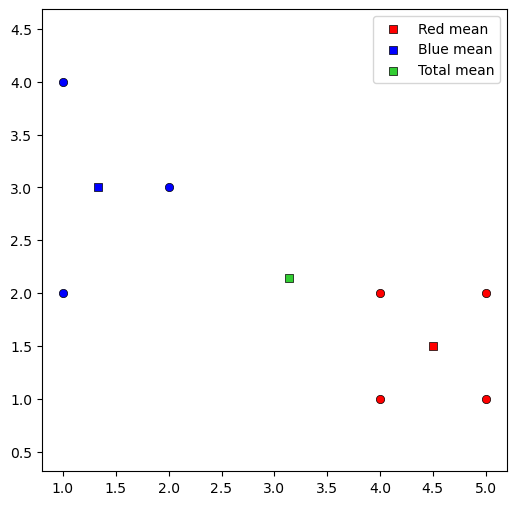

In [162]:
# Data
RED=np.array([[5,2],[5,1], [4,1],[4,2]])
BLUE=np.array([[1,4],[2,3],[1,2]])
Total=np.concatenate((RED, BLUE))

plt.figure(figsize = (6, 6))
plt.axis('equal')

xr,yr=RED.T
plt.scatter(xr,yr,color='r', edgecolors='black',linewidths=0.5)
xb,yb=BLUE.T
plt.scatter(xb,yb,color='b', edgecolors='black',linewidths=0.5)

#Means of each class and overall mean
mr=np.mean(RED,axis=0)
mb=np.mean(BLUE,axis=0)
M=np.mean(Total,axis=0)

plt.scatter(mr[0],mr[1],color='r',marker='s', edgecolor='black', linewidths=0.5, label='Red mean')
plt.scatter(mb[0],mb[1],color='b', marker='s', edgecolor='black', linewidths=0.5, label='Blue mean')
plt.scatter(M[0],M[1],color='limegreen', marker='s', edgecolor='black', linewidths=0.5, label='Total mean') 

plt.legend()
plt.show()

We want to find a line such that, after projecting the data onto it, the separation between the classes is large and the spread of the data within each class is small. 

Since we are only interested in the direction of the line, we can assume that it passes through the origin and is in the direction of a unit vector ${\bf v}$. Recall that the projection of a vector ${\bf x}$ onto a line through the origin in the direction of a unit vector ${\bf v}$ is given by $$proj_{\bf v}({\bf x})=\frac{{\bf v} \cdot {\bf x}}{{\bf v} \cdot {\bf v}}{\bf v} =({\bf v}^T {\bf x}){\bf v} $$

First, let us measure the distance between the projected class means. Note that we are considering the *projected means*, not the original means. 

Let $C_1$ and $C_2$ denote the two classes, containing $n_1$ and $n_2$ data points, respectively. Let ${\bf x}_i$ be a data point, and $\hat{\bf x}_i$ its projection. Denote the original class means by ${\bf m}_1$ and ${\bf m}_2$, and the means of the projected data by $\hat{\bf m}_1$ and $\hat{\bf m}_2$. Then, for $j=1, 2$:
$$\hat{\bf m}_j=\frac{1}{n_j}\sum_{{\bf x}_i\in C_j}\hat{\bf x}_i=\frac{1}{n_j}\sum_{{\bf x}_i\in C_j}({\bf v}^T{\bf x}_i){\bf v}=\left({\bf v}^T\frac{1}{n_j}\sum_{{\bf x}_i\in C_j}{\bf x}_i\right){\bf v}=({\bf v}^T {\bf m}_j){\bf v} = proj_{\bf v}({\bf m}_j)$$

Hence, the mean of the projected data is simply the projection of the original class mean.

Maximize distance between projected class means is equivalent to maximizing square distance: $||\hat{\bf m}_1-\hat{\bf m}_2||^2$.

Using definition of the projection we have:
$$||\hat{\bf m}_1-\hat{\bf m}_2||^2=||({\bf v}^T {\bf m}_1){\bf v}-({\bf v}^T {\bf m}_2){\bf v}||^2=||({\bf v}^T({\bf m}_1-{\bf m}_2)){\bf v}||^2$$

Since ${\bf v}^T({\bf m}_1-{\bf m}_2)$ is a scalar we can take it outside the norm:

$$||({\bf v}^T({\bf m}_1-{\bf m}_2)){\bf v}||^2=({\bf v}^T({\bf m}_1-{\bf m}_2))^2||{\bf v}||^2=({\bf v}^T({\bf m}_1-{\bf m}_2))^2={\bf v}^T({\bf m}_1-{\bf m}_2)({\bf m}_1-{\bf m}_2)^T{\bf v}$$

The matrix $({\bf m}_1-{\bf m}_2)({\bf m}_1-{\bf m}_2)^T$ is the outer product of ${\bf m}_1-{\bf m}_2$ with itself. It is square, symmetric, and positive semidefinite. We define the **between-class scatter matrix** $S_b$ as $$S_b=({\bf m}_1-{\bf m}_2)({\bf m}_1-{\bf m}_2)^T$$

Thus, maximizing the squared distance between the projected means is equivalent to maximizing a quadratic form ${\bf v}^TS_b{\bf v}$.

Note: In the two class case, $rank(S_b)$ is at most $1$. If the two class means are different, then $rank(S_b)\neq 0$ and therefore $rank(S_b)=1$. More generally, we will prove later that the between-class scatter matrix has rank at most $C-1$, where $C$ is the number of classes. THis will imply that LDA can reduce the data to at most $C-1$ dimensions. In particular, with two classes, LDA can reduce the data to at most one dimension.

In [163]:
Sb=np.outer(mr-mb,mr-mb)
print(Sb)

[[10.03 -4.75]
 [-4.75  2.25]]


In [165]:
print(f'Rank(S_b) = {np.linalg.matrix_rank(Sb)}')

Rank(S_b) = 1


To minimize the within-class scatter, we want the projected data within each class to be as tightly clustered as possible. Thus, we want to minimize **scatter** of the two projected classes, denoted by $\hat{s}_1^2$ and $\hat{s}_2^2$. The scatter of class $j$ is defined by $$\hat{s}_j^2=\sum_{{\bf x}_i\in C_j}||(\hat{\bf x}_i-\hat{\bf m}_j)||^2$$

Note: Scatter is similar to variance, but it is not normalized by the number of data points. Specifically, the sample variance is obtained by dividing the scatter by $\frac{1}{n_j-1}$. It is possible to use variance as well. However, using scatter or variance in the LDA criterion can lead to different optimal discriminant directions, especially when the classes have different sizes. In this chapter, we use the scatter-based approach, which is standard in LDA.

We want to minimize $\hat{s}_1^2+\hat{s}_2^2$.  For $j=1,2$: 

$$\begin{aligned}
\hat{s}_j^2 &= \sum_{{\bf x}_i\in C_j}||\hat{\bf x}_i-\hat{\bf m}_j||^2\\
&=\sum_{{\bf x}_i\in C_j}||{\bf v}^T({\bf x}_i-{\bf m}_j){\bf v}||^2\\
&=\sum_{{\bf x}_i\in C_j}\left({\bf v}^T({\bf x}_i-{\bf m}_j)\right)^2\\
&={\bf v}^T\left(\sum_{{\bf x}_i\in C_j}({\bf x}_i-{\bf m}_j)({\bf x}_i-{\bf m}_j)^T\right){\bf v}
\end{aligned}$$

Define $$S_j= \sum_{{\bf x}_i\in C_j}({\bf x}_i-{\bf m}_j)({\bf x}_i-{\bf m}_j)^T$$
We call $S_j$ the **within-class scatter matrix for class $j$**. Therefore,
$$\hat{s}_j^2={\bf v}^TS_j{\bf v}$$

We define the **total within-class scatter matrix** as $S_w=S_1+S_2$. Consequently,
$$ \hat{s}_1^2+\hat{s}_2^2={\bf v}^T S_1 {\bf v}+{\bf v}^T S_2 {\bf v}={\bf v}^T (S_1+S_2) {\bf v} = {\bf v}^T S_w {\bf v}$$

The matrix $S_w$ is also square, symmetric and positive semidefinite. And so, minimimizing the within-class is equivalent to minimizing a quadratic form ${\bf v}^TS_w{\bf v}$. 

Note that while it is possible that $S_w$ is singular, in most practical situations it is invertible.

In [166]:
S1=np.zeros((2,2))
for i in range(len(RED)):
    S1=S1+np.outer(RED[i]-mr, RED[i]-mr)
S2=np.zeros((2,2))
for i in range(len(BLUE)):
    S2=S2+np.outer(BLUE[i]-mb, BLUE[i]-mb)
Sw=S1+S2
print(Sw)

[[1.67 0.  ]
 [0.   3.  ]]


We can combine both goals into a single optimization problem by maximizing $$\frac{{\bf v}^T S_b {\bf v}}{{\bf v}^T S_w {\bf v}}$$

This ratio is large when the projected class means are far apart and the projected data within each class are tightly clustered. In other words, we want a large numerator and a small denominator.

**Note**: We do not need to impose the constraint $||{\bf v}||=1$. Multiplying ${\bf v}$ by any nonzero scalar multiplies both the numerator and denominator by the same factor, leaving the ratio unchanged.

We already know how eigenvalues and eigenvectors arise when maximizing a quadratic form subject to a normalization constraint. The problem above is closely related, but now we have a ratio of quadratic forms.

---

**Theorem** Let $S_w$ and $S_b$ be symmetric matrices. Then the maximum of
$$\frac{{\bf v}^T S_b {\bf v}}{{\bf v}^T S_w {\bf v}}$$ over all non-zero vectors $\bf v$ is the largest generalized eigenvalue $\lambda$ satisfying  $$S_b{\bf v}=\lambda S_w {\bf v}$$ If $S_w$ is invertible, then equivalently, $\lambda$ is the largest eigenvalue of $S_w^{-1}S_b$. The associated eigenvector in either case gives the optimal projection direction. This direction is called the **discriminant direction**.



In [168]:
print(f'Rank(S_w) = {np.linalg.matrix_rank(Sw)}')

Rank(S_w) = 2


Since $S_w$ is a $ 2 \times 2$ matrix with rank $2$, it is invertible. So, we find eigenvalues and eigenvectors of $S_w^{-1}S_b$.

In [169]:
print(f'Eigenvalues \n{np.linalg.eig(np.linalg.inv(Sw)@Sb)[0]}')
print(f'Eigenvectors \n{np.linalg.eig(np.linalg.inv(Sw)@Sb)[1]}')

Eigenvalues 
[6.77 0.  ]
Eigenvectors 
[[ 0.97  0.43]
 [-0.25  0.9 ]]


The first eigenvalue is the largest. The `np.linalg.eig` doesn't usually order eigenvalues. If you would like to make sure they are sorted in descending order, you can use `.argsort()[::-1]`.

In [170]:
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(Sw)@Sb)
idx = eigenvalues.argsort()[::-1]

sorted_eigenvalues = eigenvalues[idx]
sorted_eigenvectors = eigenvectors[:, idx]
print(sorted_eigenvalues)

[6.77 0.  ]


Let's plot the data together with its projection on the line spanned by the eigenvector corresponding to the largest eigenvalue

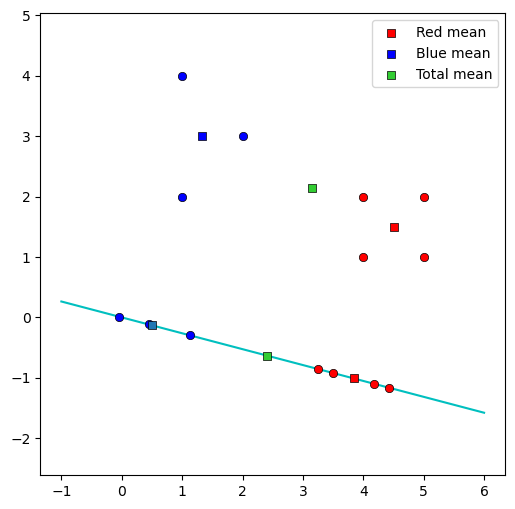

In [171]:
v=sorted_eigenvectors[:,0]

# Calculating projections:

Bp=(BLUE@v).reshape(-1,1)*v
Rp=(RED@v).reshape(-1,1)*v
mrp=(mr@v)*v
mbp=(mb@v)*v
mp=(M@v)*v

plt.figure(figsize = (6, 6))
plt.axis('equal')

# Ploting the line:

lx=np.linspace(-1,6,100)
ly=lx*v[1]/v[0]
plt.plot(lx,ly,'-c', zorder=0)  

# Original data

plt.scatter(xr,yr,color='r', edgecolors='black',linewidths=0.5)
plt.scatter(xb,yb,color='b', edgecolors='black',linewidths=0.5)

plt.scatter(mr[0],mr[1],color='r',marker='s', edgecolor='black', linewidths=0.5, label='Red mean')
plt.scatter(mb[0],mb[1],color='b', marker='s', edgecolor='black', linewidths=0.5, label='Blue mean')
plt.scatter(M[0],M[1],color='limegreen', marker='s', edgecolor='black', linewidths=0.5, label='Total mean') 

# Plotting projections

plt.scatter(Rp[:,0],Rp[:,1], color='r', edgecolors='black',linewidths=0.5)
plt.scatter(Bp[:,0],Bp[:,1], color='b', edgecolors='black',linewidths=0.5)

plt.scatter(mrp[0],mrp[1], color='r',marker='s', edgecolor='black', linewidths=0.5)
plt.scatter(mbp[0],mbp[1], marker='s', edgecolor='black', linewidths=0.5)
plt.scatter(mp[0],mp[1],color='limegreen', marker='s', edgecolor='black', linewidths=0.5) 

plt.legend()
plt.show()

Hence, we reduced the dimensionality of the data from 2 to 1 while preserving the information that is most useful for distinguishing the two classes. 

## LDA with more than two classes

When we have more than two classes, we still want to construct the within-class and between-class scatter matrices. The within-class scatter matrix is constructed in the same way as in the two-class case. However, to construct the between-class scatter matrix for more than two classes, it is more convenient to measure the separation of the classes by considering the distances between each class mean and the global mean.

Let $C$ be number of classes. Let $N_j$ denote the size of class $j$, ${\bf m}_j$ denote the mean of class $j$, and $\bf M$ denote the global mean. We define between-class scatter matrix by $$ S_b=\sum_{j=1}^{C}N_j ({\bf m}_j-{\bf M}) \cdot ({\bf m}_j-{\bf M})^T$$

Notice that the contribution of each class is weighted by its size $N_j$. So, larger classes have a greater influence on the between-class scatter matrix.

As before, we seek a direction ${bf v}$ that maximizes $$\frac{{\bf v}^T S_b {\bf v}}{{\bf v}^T S_w {\bf v}}$$

As in the two class case, if $S_w$ is invertible, we can find the discriminant directions by examining the eigenvalues and eigenvectors of $S_w^{-1}S_b$; otherwise, we solve the generalized eigenvalue problem $S_b{\bf v}=\lambda S_w {\bf v}$.

The following theorem establishes an important limit on the number of discriminant directions.

---
**Theorem.**

Let $S_b$ be between-class matrix for a data set with $C$ classes. Then $$rank(S_b) \leq C-1$$
**Proof.**


Using notation from the definition of $S_b$, let ${\bf d}_j=\sqrt{N_j}({\bf m}_j-{\bf M})$. Then we can rewrite $S_b$ as $$S_b=\sum_{j=1}^C {\bf d}_j{\bf d}_j^T = DD^T,$$ where $D=\begin{bmatrix} {\bf d}_1 & \cdots & {\bf d}_C\end{bmatrix}$.

Let $N=N_1+ \cdots + N_C$ be the total number of data points. Since the global mean is the weighted average of the class means, $$\sum_{j=1}^C N_j{\bf m}_j=N{\bf M}$$
Therefore, we have  $$\sum_{j=1}^C N_j({\bf m}_j-{\bf M})={\bf 0}$$

Substituting ${\bf d}_j=\sqrt{N_j}({\bf m}_j-{\bf M})$, we obtain $$\sum_{j=1}^C N_j({\bf m}_j-{\bf M})=\sum_{j=1}^C \sqrt{N_j}\sqrt{N_j}({\bf m}_j-{\bf M})=\sum_{j=1}^C \sqrt{N_j}{\bf d}_j={\bf 0}$$
Therefore, the columns of $D$ are linearly dependent. Hence, since $D$ has $C$ columns, $rank(D) \leq C-1$.

Finally, since $S_b=DD^T$, we have $$rank(S_b) = rank(DD^T) = rank(D) \leq C-1$$

---
It follows that LDA can produce at most $C−1$ nonzero discriminant directions. 

**Note**: If $S_w$ is invertible, then multiplication by $S_w^{-1}$ does not change the rank and so, $rank(S_w^{-1}S_b)=rank(S_b)$. This means that LDA can produce at most $C-1$ nonzero discriminant directions. 

If $S_w$ is not invertible, we have to consider generalized eigenvalue problem $S_b{\bf v}=\lambda S_w {\bf v}$. However, the amount of discriminant directions can not be higher than rank of $S_b$. Therefore, the upper bound of $C-1$ is still true.

**Warning**: We need to be careful when visualizing the “projected space.” LDA does not, in general, produce mutually perpendicular projection directions in the original feature space. Although $S_b$ and $S_w$ are symmetric matrices, the product $S_w^{-1}S_b$ is generally not symmetric. Consequently, its eigenvectors are not necessarily orthogonal. A plot that treats the discriminant directions as perpendicular axes can be useful for visualizing the transformed coordinates, but it should not be interpreted as an orthogonal coordinate system in the original feature space.

--- 

Let us now apply LDA to a Penguin set with three classes.

In [11]:
df=pd.read_csv('Penguins_size_clean.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
3,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
4,Adelie,Torgersen,39.3,20.6,190,3650,MALE


We will use five numerical measurements as predictors and the penguin species as the class label. Our goal is to reduce the data to two dimensions using LDA. Let us create two arrays: $X$, which stores the five measurements for each penguin, and $y$, which stores the corresponding species labels.

In [12]:
X=np.array(df.iloc[:,2:6])
y=np.array(df.iloc[:,0])

Compute the mean vector for each class.

In [13]:
mean_vectors = []
for i,cl in enumerate(np.unique(y)):
    mean_vectors.append(np.mean(X[y==cl], axis=0))   #note how we selected rows in X based on class in y.
    print(f'Mean Vector of the class {cl}: { mean_vectors[i]} \n' )

Mean Vector of the class Adelie: [  38.82   18.35  190.1  3706.16] 

Mean Vector of the class Chinstrap: [  48.83   18.42  195.82 3733.09] 

Mean Vector of the class Gentoo: [  47.57   15.    217.24 5092.44] 



Next, compute $S_w$.

In [18]:
Sw = np.zeros((4,4))

for i,cl in enumerate(np.unique(y)):
    class_sc_mat = np.zeros((4,4))                         
    for row in X[y == cl]:
        class_sc_mat = class_sc_mat + np.outer(row-mean_vectors[i],row-mean_vectors[i])
    Sw = Sw + class_sc_mat                            
    
print(f'Within-class Scatter Matrix: \n {Sw}')

Within-class Scatter Matrix: 
 [[    2913.52      583.99     3192.34   263083.58]
 [     583.99      416.67     1217.73   106898.12]
 [    3192.34     1217.73    14692.75   596616.36]
 [  263083.58   106898.12   596616.36 70069446.8 ]]


Now compute $S_b$.

In [19]:
overall_mean = np.mean(X, axis=0)

Sb = np.zeros((4,4))
for i, cl in enumerate(np.unique(y)):  
    n = X[y==cl,:].shape[0]                    # size of each class
    Sb = Sb + n * np.outer(mean_vectors[i] - overall_mean,mean_vectors[i] - overall_mean)
print(f'Between-class Scatter Matrix: \n  {Sb}')


Between-class Scatter Matrix: 
  [[ 7.02e+03 -1.40e+03  1.34e+04  5.99e+05]
 [-1.40e+03  8.71e+02 -6.51e+03 -3.55e+05]
 [ 1.34e+04 -6.51e+03  5.05e+04  2.67e+06]
 [ 5.99e+05 -3.55e+05  2.67e+06  1.45e+08]]


Let us check the rank of $S_b$ and $S_w$.

In [20]:
print(f'Rank of S_b = {np.linalg.matrix_rank(Sb)}')
print(f'Rank of S_w = {np.linalg.matrix_rank(Sw)}')

Rank of S_b = 2
Rank of S_w = 4


Since the dataset contains three classes, the $rank(S_b)$ cannot exceed two. If the three class means are not collinear in the five-dimensional feature space, the rank will typically be two. 

So, we can reduce our data to either 1 or 2 dimensions using LDA. In this example, let us reduce the data to two discriminant directions. Since the $ranbk(S_w)$ is the same as number of features, $S_w$ is invertible. Therefore, we consider eigenvalues of $S_w^{-1}S_b$. There are two non-zero eigenvalues.

In [23]:
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(Sw)@Sb)
idx = eigenvalues.argsort()[::-1]

sorted_eval = eigenvalues[idx]
sorted_evec = eigenvectors[:, idx]

for i in range(2):
    eigvec_sc = sorted_evec[:,i].reshape(-1,1)           #converting to column for a nicer display.
    print(f'Eigenvector {i+1} : \n { eigvec_sc} ')
    print(f'Eigenvalue {i+1}: {sorted_eval[i]:.2f}')

Eigenvector 1 : 
 [[-0.08]
 [ 0.99]
 [-0.08]
 [-0.  ]] 
Eigenvalue 1: 15.03
Eigenvector 2 : 
 [[ 1.  ]
 [ 0.02]
 [-0.03]
 [-0.  ]] 
Eigenvalue 2: 2.34


The eigenvectors define the discriminant directions. Their entries are the coefficients used to construct the discriminant coordinates from the original features, similar to the role of principal components in PCA. For example, the first eigenvector defines the first discriminant coordinate $LD_1$:

$$ LD_1 = 0.1x_1-0.83x_2+0.07x_3+0x_4+0.54x_5$$

where $x_1, \cdots, x_5$ represent the five original features.

If $X$ is a data matrix and $W$ is the matrix whose columns are the first two discriminant directions, then $X_{LDA}=XW$ is the transformed dataset, with two discriminant coordinates for each observation.

In [24]:
W = sorted_evec[:,:2]
X_lda = X@W

Let us plot the transformed data. For visualization, we will plot $LD_1$ and $LD_2$ along the horizontal and vertical axes, respectively. These are coordinates in the transformed space; as noted above, the corresponding directions in the original feature space need not be orthogonal. In fact, you can check that the two eigenvectors are not orthogonal in this example.

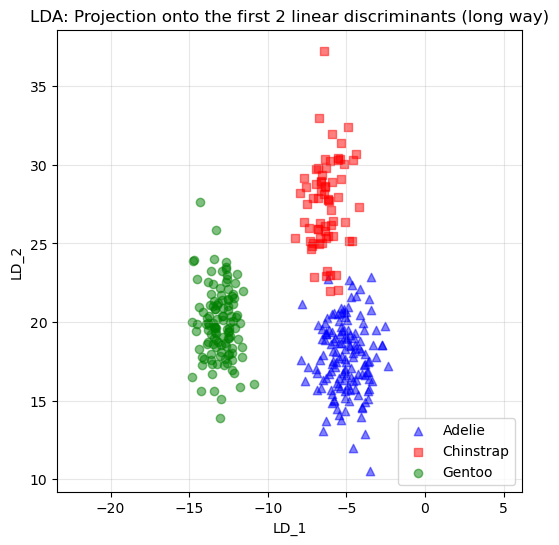

In [25]:
plt.figure(figsize = (6, 6))
plt.axis('equal')

for label,marker,color in zip(np.unique(y),('^', 's', 'o'),('blue', 'red', 'green')):
    plt.scatter(x=X_lda[:,0][y == label], y=X_lda[:,1][y == label],  
            marker=marker, color=color, alpha=0.5, label=label)

plt.xlabel('LD_1')
plt.ylabel('LD_2')

plt.legend(loc='lower right', fancybox=True)
plt.title('LDA: Projection onto the first 2 linear discriminants (long way)')

plt.grid(alpha=0.3)
plt.show()

We can also use `sklearn` library to apply LDA. This provides a convenient way to obtain the lower-dimensional representation without manually constructing the scatter matrices and solving the eigenvalue problem.

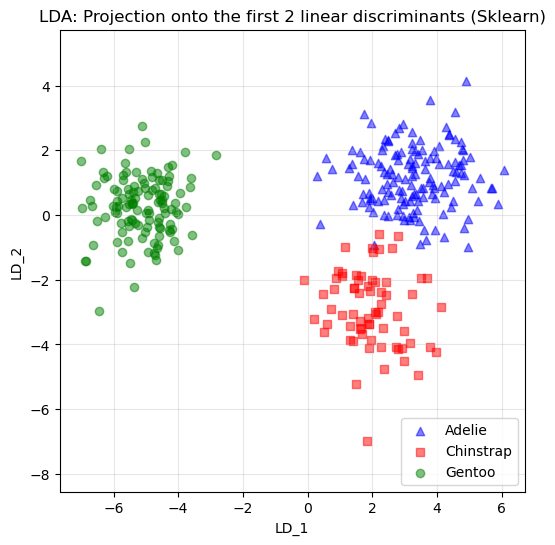

In [28]:
sklearn_lda = LDA(n_components=2)          
X_lda_sk = sklearn_lda.fit_transform(X, y)

# that is it. now we just plot again:

plt.figure(figsize = (6, 6))
plt.axis('equal')

for label,marker,color in zip(np.unique(y),('^', 's', 'o'),('blue', 'red', 'green')):
    plt.scatter(x=X_lda_sk[:,0][y == label], y=X_lda_sk[:,1][y == label],  
            marker=marker, color=color, alpha=0.5, label=label)

plt.xlabel('LD_1')
plt.ylabel('LD_2')

plt.legend(loc='lower right', fancybox=True)
plt.title('LDA: Projection onto the first 2 linear discriminants (Sklearn)')

plt.grid(alpha=0.3)
plt.show()

**Note**: If you look carefully, you should see that we got different result using `sklearn`. There are several possible reasons for these differences:

1. Sign of the eigenvectors: An eigenvector and its negative define the same discriminant direction. However, the resulting plot will be flipped.
2. Scaling: The discriminant directions may be scaled differently. Thus, even when the directions agree, the projected coordinates may have different magnitudes.
3. Different solvers: By default, `sklearn` uses the SVD solver to perform LDA. To use an approach closer to our manual eigenvalue-based derivation, you can specify `solver='eigen`. For example, `LDA(n_components=2, solver='eigen)'.
4. Within-class scatter: Our manual calculation uses the within-class scatter matrix, whereas `sklearn` estimates and combines class covariance matrices. These matrices may differ in both scaling and weighting, which can lead to different discriminant directions as well as different projected coordinates.

Despite these differences, the methods may produce equivalent discriminant directions, even if the signs and magnitudes of the projected coordinates differ.

As a bonus, at the end of this notebook, you can code where we apply logistic regression to the LDA-transformed data and plot the resulting decision regions. 

## Applying LDA to the handwritten-digit dataset

In the previous chapter, we applied PCA to the handwritten-digit dataset to reduce its dimensionality to three. Let us perform the same dimensionality reduction using LDA and compare the class separation with the results obtained using PCA.

In [29]:
X, y = load_digits(return_X_y=True)
X.shape, y.shape

((1797, 64), (1797,))

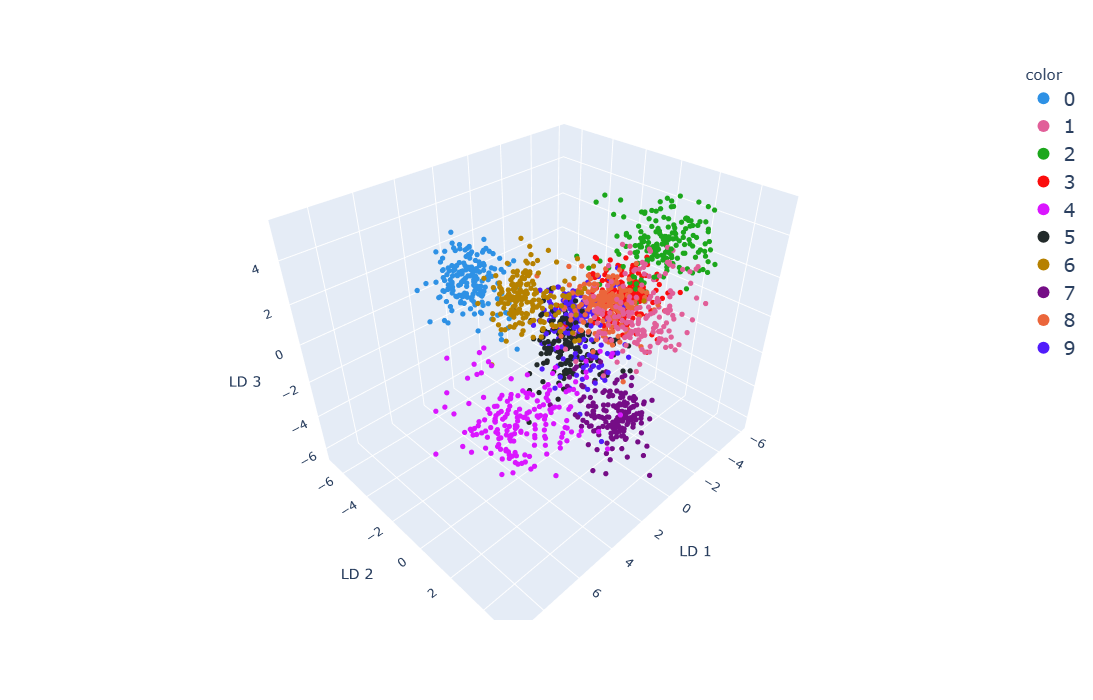

In [30]:
sklearn_lda = LDA(n_components=3)          
X_lda_sk = sklearn_lda.fit_transform(X, y)

fig = px.scatter_3d(
    x=X_lda_sk[:, 0], y=X_lda_sk[:, 1], z=X_lda_sk[:, 2],
    color=y.astype(str),color_discrete_sequence=px.colors.qualitative.Dark24)

fig.update_traces(marker_size=3)

fig.update_layout(
    width=700, height=700,
    scene=dict(xaxis_title='LD 1', yaxis_title='LD 2', zaxis_title='LD 3', aspectmode='data'),
    legend=dict(itemsizing="constant", font=dict(size=19), title_font=dict(size=15)))

fig.show()

## Decision boundary using LDA and Logistic Regression

Finally, we will use logistic regression to classify the penguin species based on their two LDA coordinates. We will plot the resulting decision regions together with the projected data points. If we are given measurements of an unknown penguin and want to predict its species, the decision regions help us identify the most likely class based on its LDA coordinates.

This example illustrates how dimensionality reduction can be combined with a classification algorithm.

In [32]:
df=pd.read_csv('Penguins_size_clean.csv')
df['species_value']=df.species.map({'Adelie':0,'Chinstrap':1, 'Gentoo':2})
X=np.array(df.iloc[:,2:6])
y=np.array(df['species_value'])

sklearn_lda = LDA(n_components=2)          
X_lda_sk = sklearn_lda.fit_transform(X, y)

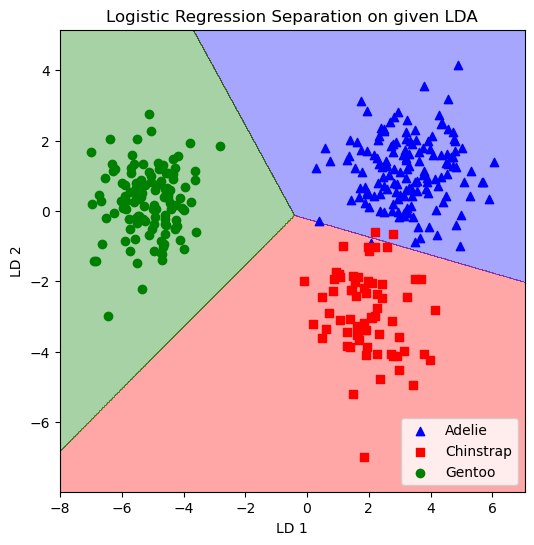

In [33]:
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(X_lda_sk, y)

plt.figure(figsize=(6, 6))

# create regions
X1, X2 = np.meshgrid(np.arange(start = X_lda_sk[:, 0].min() - 1, stop = X_lda_sk[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_lda_sk[:, 1].min() - 1, stop = X_lda_sk[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.35, cmap = ListedColormap(['blue', 'red', 'green']))

# plot the data
for label,marker,color, species in zip(
    np.unique(y),('^', 's', 'o'),('blue', 'red', 'green'),('Adelie','Chinstrap', 'Gentoo')):
    
    plt.scatter(X_lda_sk[y == label, 0], X_lda_sk[y == label, 1],
                c = color, marker=marker, label = species)
    
plt.title('Logistic Regression Separation on given LDA')
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower right', fancybox=True)

plt.show()